## iris数据集

鸢尾花（iris）数据集是一个经典数据集，在统计学习和机器学习领域都经常被用作示例。数据集内包含 3 类共 150 条记录，每类各 50 个数据，每条记录都有 4 项特征：花萼长度、花萼宽度、花瓣长度、花瓣宽度，可以通过这4个特征预测鸢尾花卉属于（iris-setosa, iris-versicolour, iris-virginica）中的哪一品种。

In [32]:
import seaborn as sns
from pandas import plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import tree

In [33]:
#加载数据集
#150条样本，每个4个特征
#sepal length (cm)  萼片长度
#sepal width (cm)   萼片宽度
#petal length (cm)  花瓣长度
#petal width (cm)   花瓣宽度

data=load_iris() 
#转换成.DataFrame形式
df=pd.DataFrame(data.data,columns=data.feature_names) #列名是特征
#print(df)
#添加品种列
df['Species']=data.target #类别标签
#查看数据信息
print(f"数据集信息: \n{df.info()}")
#查看前5条
print(f"前5条数据: \n{df.head()}")
# 查看各特征列的摘要信息
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
数据集信息: 
None
前5条数据: 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


C:\Users\DELL\AppData\Local\Temp\ipykernel_39004\2252762635.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Species', y=df.columns[0], data=df, palette=antV, ax=axes[0, 0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_39004\2252762635.py:7: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.violinplot(x='Species', y=df.columns[0], data=df, palette=antV, ax=axes[0, 0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_39004\2252762635.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Species', y=df.columns[1], data=df, palette=antV, ax=axes[0, 1])
C:\Users\DELL\AppData\Local\Temp\ipykernel_39004\2252762635.py:8: UserWarning: The pale

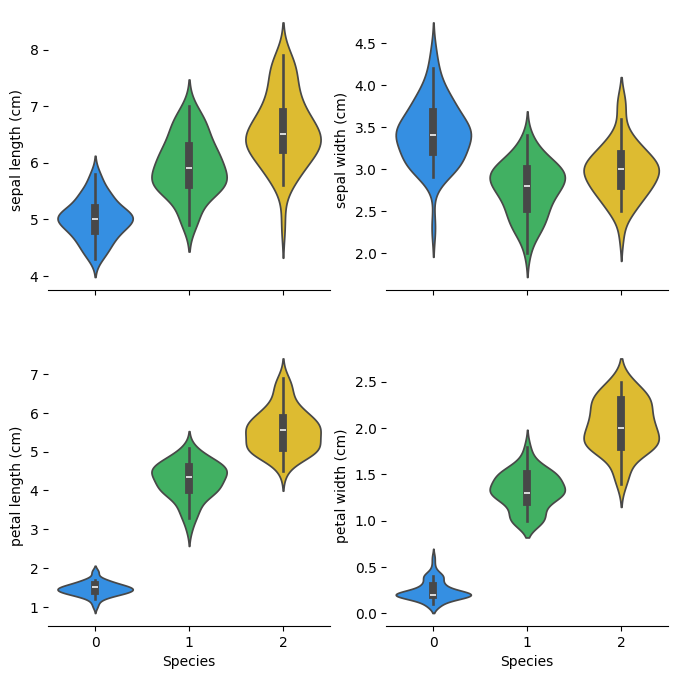

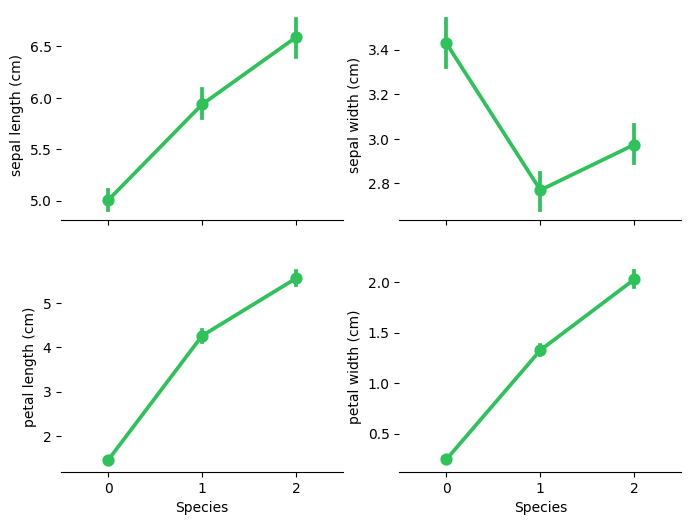

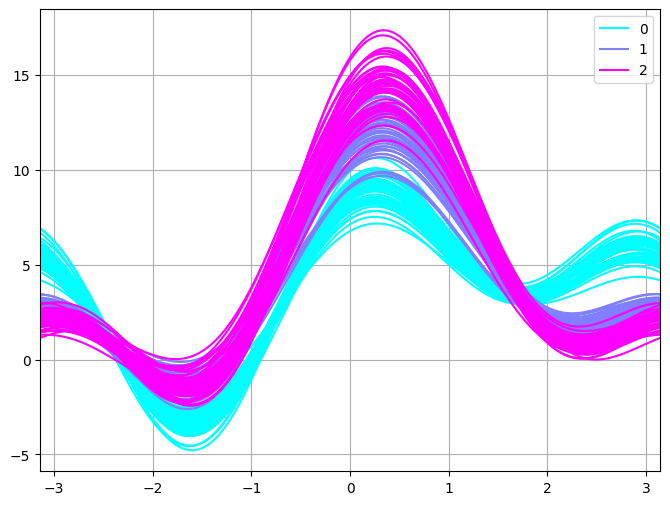

In [34]:
# 设置颜色主题
antV = ['#1890FF', '#2FC25B', '#FACC14', '#223273', '#8543E0', '#13C2C2', '#3436c7', '#F04864'] 
# 绘制violinplot
f, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True) #4个子图
sns.despine(left=True) # 删除上方和右方坐标轴上不需要的边框，这在matplotlib中是无法通过参数实现的
#横轴是花的类别，纵轴是第一个特征，data是前面的DataFrame
sns.violinplot(x='Species', y=df.columns[0], data=df, palette=antV, ax=axes[0, 0])
sns.violinplot(x='Species', y=df.columns[1], data=df, palette=antV, ax=axes[0, 1])
sns.violinplot(x='Species', y=df.columns[2], data=df, palette=antV, ax=axes[1, 0])
sns.violinplot(x='Species', y=df.columns[3], data=df, palette=antV, ax=axes[1, 1])
plt.show()

# 绘制pointplot
f, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
sns.despine(left=True) 
sns.pointplot(x='Species', y=df.columns[0], data=df, color=antV[1], ax=axes[0, 0])
sns.pointplot(x='Species', y=df.columns[1], data=df, color=antV[1], ax=axes[0, 1])
sns.pointplot(x='Species', y=df.columns[2], data=df, color=antV[1], ax=axes[1, 0])
sns.pointplot(x='Species', y=df.columns[3], data=df, color=antV[1], ax=axes[1, 1])
plt.show()

# g = sns.pairplot(data=df, palette=antV, hue= 'Species')
# 安德鲁曲线
#把一条样本记录，也就是一朵花的4个特征，转换成一条曲线
#它会把每一条样本记录，也就是一朵花的 4 个特征，转换成一条曲线。
#如果同一类别的曲线比较集中，说明这一类样本比较相似。
plt.subplots(figsize = (8,6))
plotting.andrews_curves(df, 'Species', colormap='cool')

plt.show()

|--- petal length (cm) <= 2.45
|   |--- class: setosa
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 5.35
|   |   |   |--- class: versicolor
|   |   |--- petal length (cm) >  5.35
|   |   |   |--- class: virginica
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: virginica
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: virginica



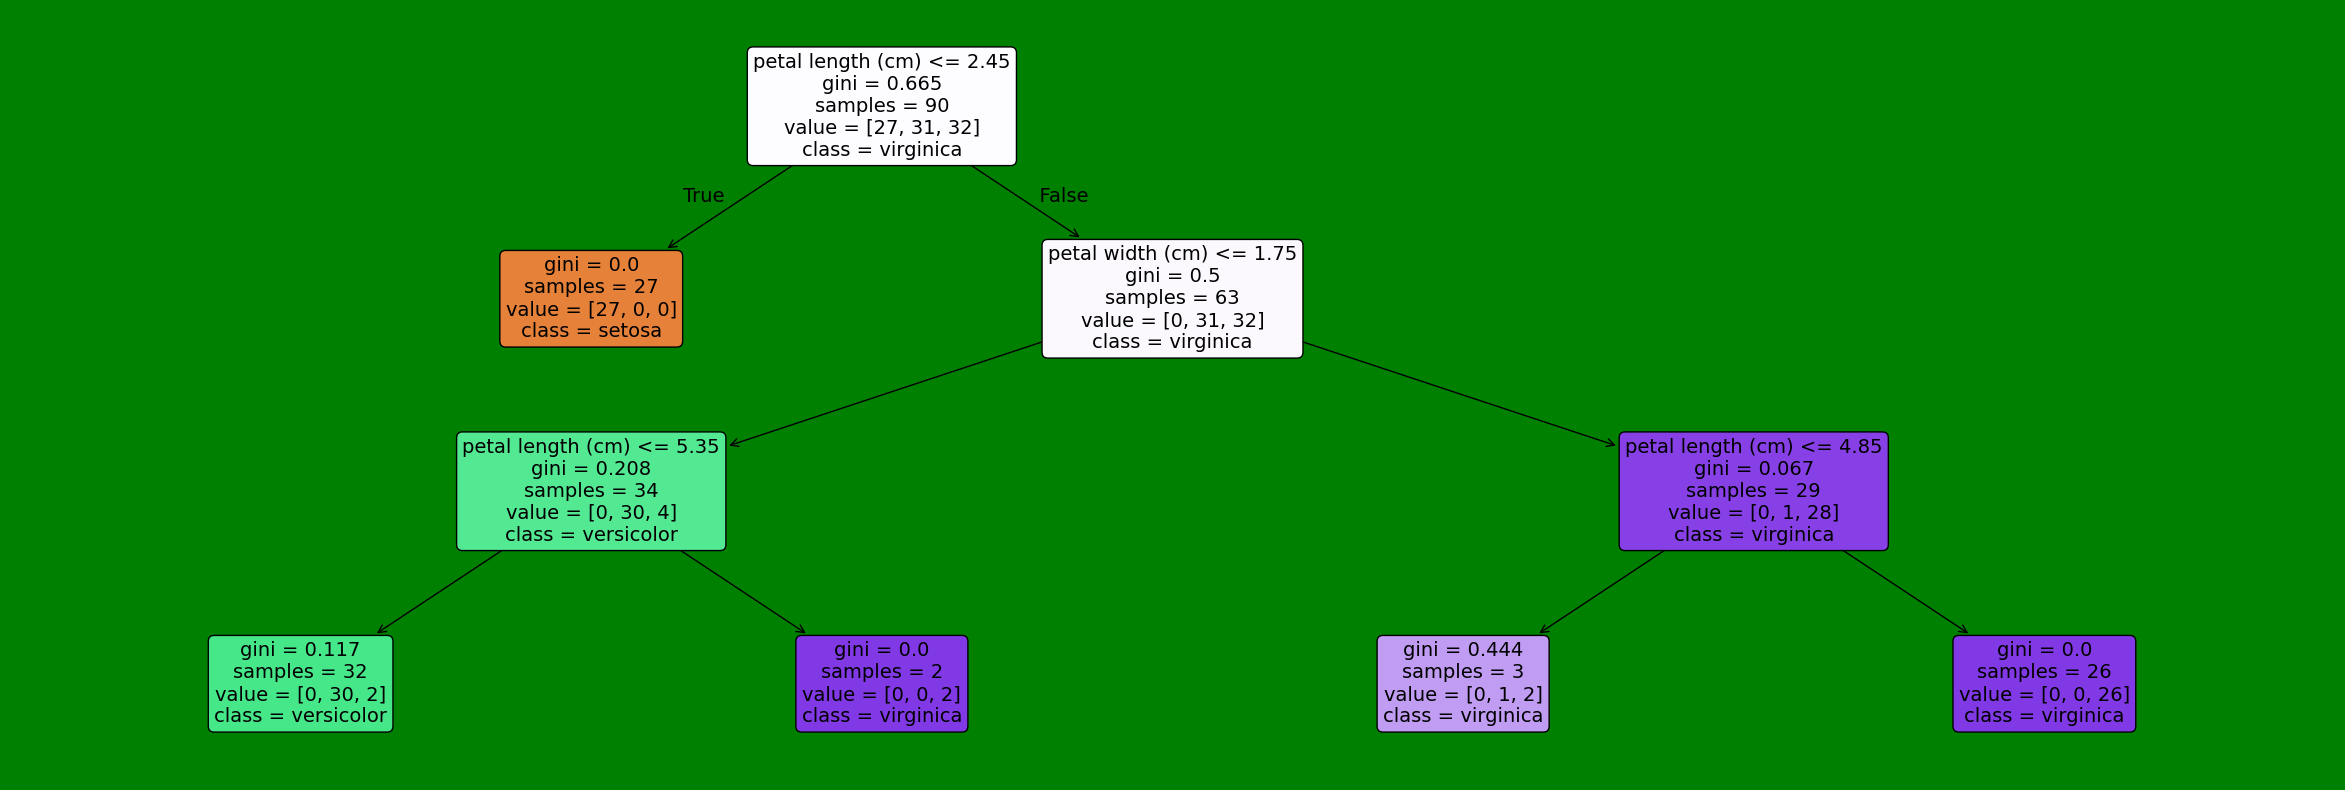

In [46]:
#加载数据集
data=load_iris()
#转换成.DataFrame形式
df=pd.DataFrame(data.data,columns=data.feature_names)
#添加品种列
df['Species']=data.target

# 用品种名替代数值标签
target=np.unique(data.target) #取出所有不重复的数字标签
target_names=np.unique(data.target_names) #取出所有不重复的品种名
targets=dict(zip(target,target_names)) #配对生成字典
df['Species']=df['Species'].replace(targets) #把对应的数字值替换成品种名
#print(df['Species'])

# 提取数据和标签
X = df.drop(columns="Species") #取Species之外的所有列作为输入特征
y = df["Species"] #作为标签
feature_names = X.columns #保存特征名
labels = y.unique() #得到不重复的标签

X_train, test_x, y_train, test_lab = train_test_split(X,y,
                                                 test_size = 0.4, #测试集占40%
                                                 random_state = 42) #随机种子
model = DecisionTreeClassifier(max_depth =3, random_state = 42)#决策树分类器
model.fit(X_train, y_train) #训练模型
#花瓣长度小于某个值，大概率是 setosa
#花瓣宽度大于某个值，大概率是 virginica

# 以文字形式输出树     
text_representation = tree.export_text(
    model,
    feature_names=list(feature_names)
)
print(text_representation)
# 用图片画出
plt.figure(figsize=(30,10), facecolor ='g') #背景颜色是绿色
tree.plot_tree(model,
                   feature_names = feature_names, #特征名 petal length <= 2.45
                   class_names = labels, #标签 setosa
                   rounded = True, #节点框圆形
                   filled = True,
                   fontsize=14)
plt.show()       

### graphiz模块

In [36]:
import os
GRAPHVIZ_PATH = r"C:\Program Files\Graphviz\bin"
if GRAPHVIZ_PATH not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + GRAPHVIZ_PATH
import graphviz

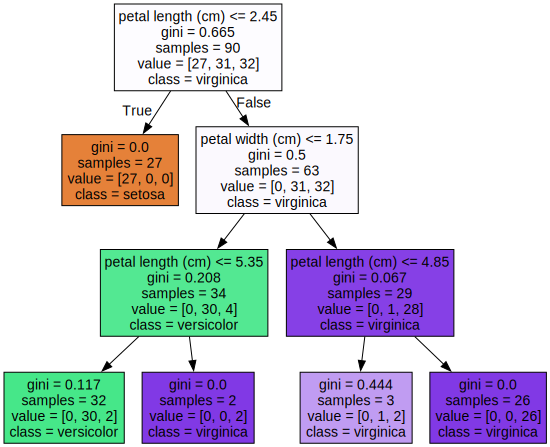

In [ ]:
dot_data=tree.export_graphviz(model,out_file=None, #不写入文件，把DOT文本返回给变量dot_data
                               feature_names=data.feature_names, #树节点显示真实特征名
                               class_names=data.target_names, #类别名字
                               filled=True)

graph=graphviz.Source(dot_data,format="png")
graph

### dtreeviz模块

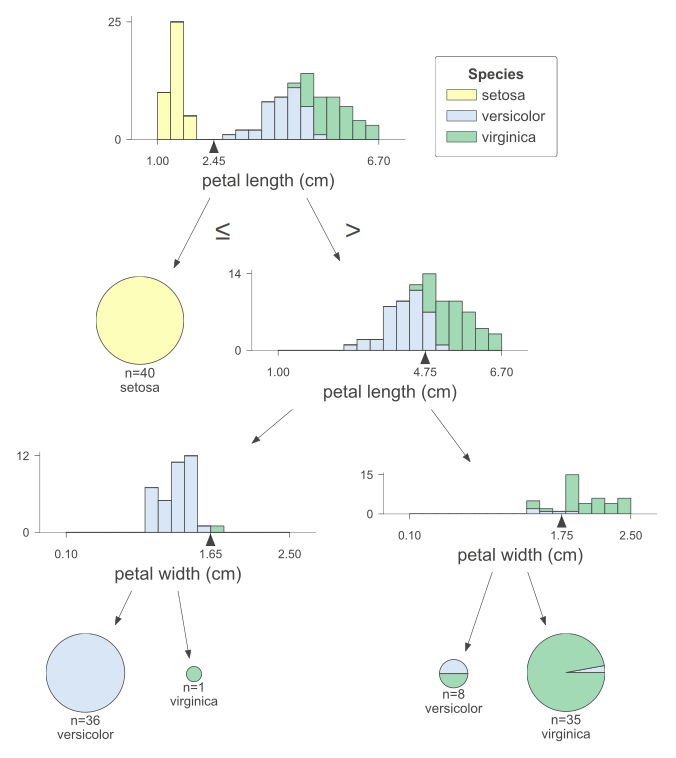

In [43]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import tree
from dtreeviz import model

dataset = load_iris()

X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

viz_model = model(
    clf,
    X_train=X_train,
    y_train=y_train,
    feature_names=dataset.feature_names,
    target_name="Species",
    class_names=list(dataset.target_names)
)

#放大显示
v=viz_model.view(scale=2.0)
v

### sns.heatmap可视化报告

[0 1 2]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



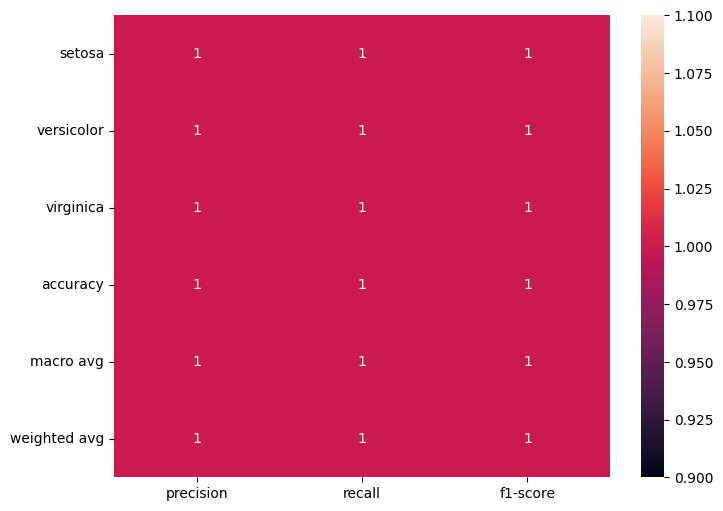

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 预测测试集
y_pred = clf.predict(X_test)

# 数字标签
labels = np.unique(dataset.target)

# 类别名字
target_names = dataset.target_names

# 打印分类报告
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=target_names
))
"""
| 指标           | 含义                       |
| ------------ | ------------------------ |
| precision    | 预测为某类的样本里，有多少是真的         |
| recall       | 某个真实类别中，有多少被成功找出来        |
| f1-score     | precision 和 recall 的综合指标 |
| support      | 测试集中该类别的真实样本数量           |
| accuracy     | 总体准确率                    |
| macro avg    | 各类别指标的简单平均               |
| weighted avg | 按样本数量加权后的平均              |

"""

# 得到字典形式的分类报告
clf_report = classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=target_names,
    output_dict=True
)

# 转成 DataFrame
report_df = pd.DataFrame(clf_report).iloc[:-1, :].T #.iloc[:-1,:]表示保留除了最后一行之外的所有行

# 画热力图
plt.figure(figsize=(8, 6))
sns.heatmap(report_df, annot=True)
plt.show()

"""
转置前是：

	setosa	versicolor	virginica
precision	...	...	...
recall	...	...	...
f1-score	...	...	...

转置后是：

	precision	recall	f1-score
setosa	...	...	...
versicolor	...	...	...
virginica	...	...	...
"""